# Random Forest Model Training

### Importing Libraries

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("/content/all_bank_stock_data_clean.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Bank,Open,High,Low,Close,Volume,GBPUSD,Open_GBX,High_GBX,Low_GBX,Close_GBX
0,2015-01-02,Lloyds,76.103240,76.381896,75.306079,75.784775,54277932,1.557972,76.103240,76.381896,75.306079,75.784775
1,2015-01-02,Barclays,241.407284,244.796165,240.759418,242.354172,20219711,1.557972,241.407284,244.796165,240.759418,242.354172
2,2015-01-02,Goldman Sachs,155.581634,155.924179,153.510394,154.872635,1877700,1.557972,9986.163218,10008.149787,9853.218595,9940.655389
3,2015-01-05,Lloyds,75.705150,76.033569,74.102872,74.262108,102525515,1.528491,75.705150,76.033569,74.102872,74.262108
4,2015-01-05,Barclays,241.506939,242.354148,233.433445,233.931808,39050852,1.528491,241.506939,242.354148,233.433445,233.931808


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8810 entries, 0 to 8809
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8810 non-null   datetime64[ns]
 1   Bank       8810 non-null   object        
 2   Open       8810 non-null   float64       
 3   High       8810 non-null   float64       
 4   Low        8810 non-null   float64       
 5   Close      8810 non-null   float64       
 6   Volume     8810 non-null   int64         
 7   GBPUSD     8810 non-null   float64       
 8   Open_GBX   8810 non-null   float64       
 9   High_GBX   8810 non-null   float64       
 10  Low_GBX    8810 non-null   float64       
 11  Close_GBX  8810 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(1), object(1)
memory usage: 826.1+ KB


## Feature Engineering

In [4]:
df['Lag1'] = df.groupby('Bank')['Close_GBX'].shift(1)
df['Lag2'] = df.groupby('Bank')['Close_GBX'].shift(2)
df['Lag3'] = df.groupby('Bank')['Close_GBX'].shift(3)
df['MA5'] = df.groupby('Bank')['Close_GBX'].transform(lambda s: s.rolling(5).mean())
df['MA10'] = df.groupby('Bank')['Close_GBX'].transform(lambda s: s.rolling(10).mean())
df['Open_Lag1'] = df.groupby('Bank')['Open_GBX'].shift(1)
df['High_Lag1'] = df.groupby('Bank')['High_GBX'].shift(1)
df['Low_Lag1'] = df.groupby('Bank')['Low_GBX'].shift(1)
df['Volume_Lag1'] = df.groupby('Bank')['Volume'].shift(1)
df.dropna(inplace=True)

encoder = LabelEncoder()
df['Bank_Name'] = df['Bank']
df['Bank'] = encoder.fit_transform(df['Bank'])
df[['Date', 'Bank_Name', 'Bank', 'Close_GBX', 'Lag1', 'Lag2', 'Lag3', 'MA5', 'MA10', 'Open_Lag1', 'High_Lag1', 'Low_Lag1', 'Volume_Lag1']].head()

,Date,Bank_Name,Bank,Close_GBX,Lag1,Lag2,Lag3,MA5,MA10,Open_Lag1,High_Lag1,Low_Lag1,Volume_Lag1
27,2015-01-15,Barclays,0,227.203888,222.818283,232.237366,230.642624,228.629214,231.514749,230.243895,232.056941,222.170402,60864512.0
28,2015-01-15,Lloyds,2,73.824234,72.550385,73.655052,73.217133,73.326625,73.560493,72.968368,73.416207,72.052782,120471280.0
29,2015-01-15,Goldman Sachs,1,9333.516981,9464.272197,9711.078458,9706.197059,9621.391147,9738.639636,9514.158619,9583.999931,9352.421772,5204700.0
30,2015-01-16,Barclays,0,223.615692,227.203888,222.818283,232.237366,227.303571,229.640901,226.755364,228.499636,218.825411,56132853.0
31,2015-01-16,Lloyds,2,74.082985,73.824234,72.550385,73.655052,73.465958,73.390314,72.729511,73.824234,71.585025,122202372.0


## Target and Features

In [5]:
X_rf = df[['Bank', 'Open_Lag1', 'High_Lag1', 'Low_Lag1', 'Volume_Lag1', 'Lag1', 'Lag2', 'Lag3', 'MA5', 'MA10']]

y_change = df['Close_GBX'] - df['Lag1']
y_close = df['Close_GBX']

## Train-Test Split

In [6]:
X_train, X_test, y_train_change, y_test_change, y_train_close, y_test_close, bank_train, bank_test = train_test_split(
    X_rf, y_change, y_close, df['Bank_Name'],
    test_size=0.2,
    shuffle=False,
)

print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (7026, 10)   Test: (1757, 10)


## Hyperparameter Tuning

In [7]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0],
}
tscv = TimeSeriesSplit(n_splits=5)
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)

search_start_time = time.time()
rf_search.fit(X_train, y_train_change)
search_time = time.time() - search_start_time

print('Best Random Forest params:', rf_search.best_params_)
print('Best CV MAE:', -rf_search.best_score_)
print(f'Hyperparameter search time: {search_time:.1f}s')

Best Random Forest params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 5}
Best CV MAE: 86.48140890347642
Hyperparameter search time: 1075.2s


## Train Final Model

In [8]:
fit_start_time = time.time()
rf = rf_search.best_estimator_
rf.fit(X_train, y_train_change)
fit_time = time.time() - fit_start_time

training_time = search_time + fit_time
print(f'Final model fit time: {fit_time:.1f}s   Total (search + fit): {training_time:.1f}s')

rf_pred_change = rf.predict(X_test)
rf_pred_close = X_test['Lag1'].values + rf_pred_change

Final model fit time: 4.5s   Total (search + fit): 1079.7s


## Evaluation (Pooled, All Three Banks)

In [9]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

pooled_metrics = evaluate(y_test_close, rf_pred_close)
print('Pooled (all 3 banks, mixed currency scale):')
for k, v in pooled_metrics.items():
    print(f'  {k}: {v:.4f}')

Pooled (all 3 banks, mixed currency scale):
  MAE: 257.5286
  RMSE: 651.2184
  MAPE: 1.9467
  R2: 0.9994


### Per-Bank Breakdown

In [10]:
per_bank_results = []

for bank_name in bank_test.unique():
    mask = (bank_test == bank_name).values
    m = evaluate(y_test_close[mask], rf_pred_close[mask])
    m['Bank'] = bank_name
    per_bank_results.append(m)

per_bank_df = pd.DataFrame(per_bank_results)[['Bank', 'MAE', 'RMSE', 'MAPE', 'R2']]
per_bank_df

,Bank,MAE,RMSE,MAPE,R2
0,Goldman Sachs,770.117711,1131.466136,1.438522,0.993674
1,Lloyds,2.144875,2.432576,2.894724,0.984500
2,Barclays,5.124606,7.035315,1.500895,0.994904


## Actual vs Predicted

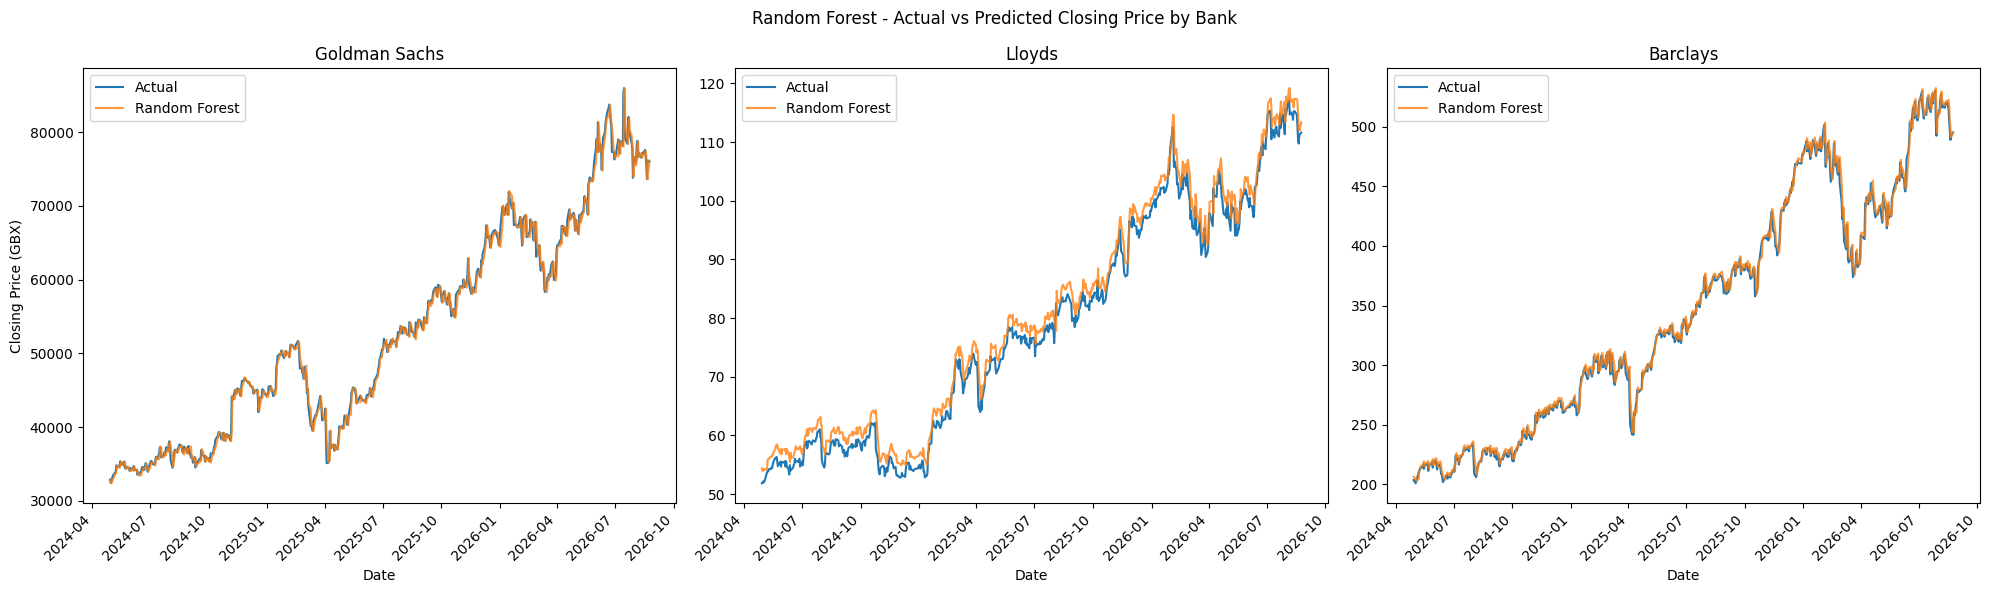

In [11]:
# Split into one panel per bank, each with real dates and its own y-axis scale,
# instead of one pooled chart. Pooling banks with very different price levels
# (Lloyds ~50-120 GBX, Goldman Sachs ~10,000-86,000 GBX) on one shared axis made
# Lloyds and Barclays invisible, squashed near zero, with only Goldman Sachs visible.
banks_in_order = bank_test.unique()
test_dates = df.loc[X_test.index, 'Date']

fig, axes = plt.subplots(1, len(banks_in_order), figsize=(20, 6))

for ax, bank_name in zip(axes, banks_in_order):
    mask = (bank_test == bank_name).values
    ax.plot(test_dates[mask], y_test_close[mask], label='Actual')
    ax.plot(test_dates[mask], rf_pred_close[mask], label='Random Forest', alpha=0.8)
    ax.set_title(bank_name)
    ax.set_xlabel('Date')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    ax.legend()

axes[0].set_ylabel('Closing Price (GBX)')
fig.suptitle('Random Forest - Actual vs Predicted Closing Price by Bank')
plt.tight_layout()
plt.show()


## Feature Importance

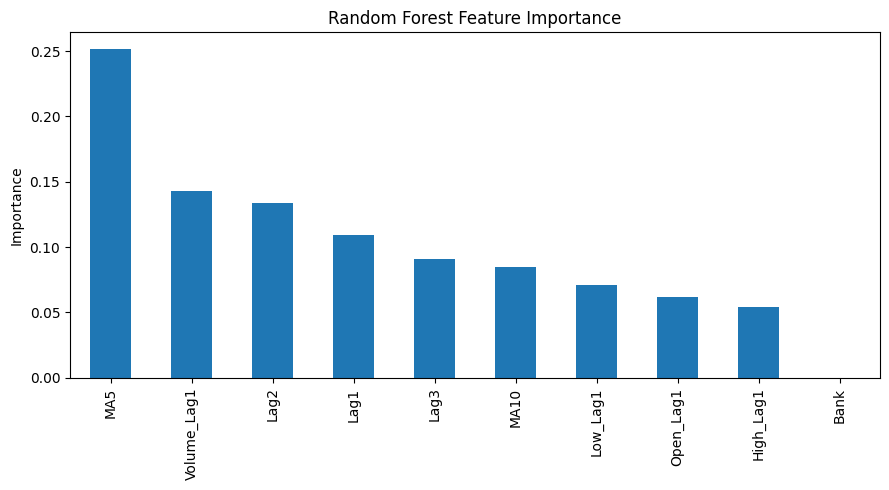

In [12]:
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Save Results

In [13]:
summary_rows = [{'Bank': 'All (pooled)', 'Model': 'Random Forest',
                 'Training_Time_Sec': training_time, **pooled_metrics}]

for row in per_bank_results:
    summary_rows.append({'Bank': row['Bank'], 'Model': 'Random Forest',
                          'Training_Time_Sec': None,
                          'MAE': row['MAE'], 'RMSE': row['RMSE'],
                          'MAPE': row['MAPE'], 'R2': row['R2']})

rf_results_summary = pd.DataFrame(summary_rows)
rf_results_summary.to_csv('random_forest_results_summary.csv', index=False)
print('Saved random_forest_results_summary.csv')
rf_results_summary

Saved random_forest_results_summary.csv


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (pooled),Random Forest,1079.724944,257.528650,651.218386,1.946695,0.999375
1,Goldman Sachs,Random Forest,NaN,770.117711,1131.466136,1.438522,0.993674
2,Lloyds,Random Forest,NaN,2.144875,2.432576,2.894724,0.984500
3,Barclays,Random Forest,NaN,5.124606,7.035315,1.500895,0.994904
